# Resumo e análise exploratória do S&P 500 (2014–2017)

Começando a análise.

Objetivo: conhecer a estrutura, cobertura temporal e qualidade do histórico diário de preços antes de avaliar padrões de mercado.

## Como os dados estão organizados?
Vamos confirmar tamanho, tipos e uma amostra legível.

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
df = pd.read_csv('../../.data/S&P 500 Stock Prices 2014-2017.csv', parse_dates=['date'])
df.shape, df.dtypes.to_frame('tipo'), df.head()

((497472, 7),
                   tipo
 symbol             str
 date    datetime64[us]
 open           float64
 high           float64
 low            float64
 close          float64
 volume           int64,
   symbol       date   open   high    low  close    volume
 0    AAL 2014-01-02  25.07  25.82  25.06  25.36   8998943
 1   AAPL 2014-01-02  79.38  79.58  78.86  79.02  58791957
 2    AAP 2014-01-02 110.36 111.88 109.29 109.74    542711
 3   ABBV 2014-01-02  52.12  52.33  51.52  51.98   4569061
 4    ABC 2014-01-02  70.11  70.23  69.48  69.89   1148391)

**Verificação de leitura:** os rótulos estão legíveis, `date` foi reconhecida como data, preços e volume são numéricos e o arquivo foi separado corretamente em sete colunas.

## Há problemas de qualidade que afetam a análise?
Vamos verificar ausências, duplicidades e consistência básica.

In [ ]:
qualidade = pd.DataFrame({
    'linhas': [len(df)],
    'duplicidades': [df.duplicated().sum()],
    'células_ausentes': [df.isna().sum().sum()],
    'ativos': [df['symbol'].nunique()],
    'data_inicial': [df['date'].min()],
    'data_final': [df['date'].max()]
})
qualidade

**Leitura executiva:** este quadro mostra se a base é adequada para exploração. Ausências, duplicidades ou cobertura desigual entre ativos precisam ser consideradas antes de comparar desempenho.

## Como a base se distribui entre os ativos?
Vamos medir registros e janela observada por ativo.

In [2]:
cobertura = (df.groupby('symbol')
                 .agg(registros=('symbol', 'size'), inicio=('date', 'min'), fim=('date', 'max'))
                 .sort_values('registros', ascending=False))
cobertura.head(10)

,registros,inicio,fim
symbol,,,
A,1007,2014-01-02,2017-12-29
MYL,1007,2014-01-02,2017-12-29
NRG,1007,2014-01-02,2017-12-29
NOV,1007,2014-01-02,2017-12-29
NOC,1007,2014-01-02,2017-12-29
NLSN,1007,2014-01-02,2017-12-29
NKE,1007,2014-01-02,2017-12-29
NI,1007,2014-01-02,2017-12-29
NFX,1007,2014-01-02,2017-12-29


**Leitura executiva:** a quantidade de registros por ativo indica se comparações futuras terão base semelhante ou se exigirão um recorte comum de datas.

## Qual é a faixa típica dos preços e do volume?
Vamos resumir as variáveis numéricas para dimensionar a escala observada.

In [3]:
df[['open', 'high', 'low', 'close', 'volume']].describe().T

,count,mean,std,min,25%,50%,75%,max
open,"497,461.00",86.35,101.47,1.62,41.69,64.97,98.41,"2,044.00"
high,"497,464.00",87.13,102.31,1.69,42.09,65.56,99.23,"2,067.99"
low,"497,464.00",85.55,100.57,1.50,41.28,64.35,97.58,"2,035.11"
close,"497,472.00",86.37,101.47,1.59,41.70,64.98,98.42,"2,049.00"
volume,"497,472.00","4,253,610.90","8,232,139.24",0.00,"1,080,166.50","2,084,896.50","4,271,928.00","618,237,630.00"


**Limitação inicial:** preços absolutos não são diretamente comparáveis entre empresas com valores nominais diferentes. Para desempenho, será mais adequado calcular retornos percentuais e controlar a janela de observação.

In [ ]:
%pip install matplotlib

In [4]:
import matplotlib.pyplot as plt

COR_PRIMARIA='#0072B2'; COR_SECUNDARIA='#94A3B8'; COR_DESTAQUE='#E69F00'; COR_EIXO='#B0B7C3'; COR_TEXTO='#334155'
PALETA=['#0072B2','#E69F00','#009E73','#CC79A7','#56B4E9','#D55E00']
plt.rcParams.update({'figure.figsize':(10,6),'figure.dpi':110,'font.size':11,'text.color':COR_TEXTO,'axes.titlesize':15,'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,'axes.prop_cycle':plt.cycler(color=PALETA)})

Matplotlib is building the font cache; this may take a moment.


## Como o mercado evoluiu no período?
Vamos acompanhar o fechamento médio diário do conjunto de ativos, uma visão agregada que evita escolher uma empresa arbitrariamente.

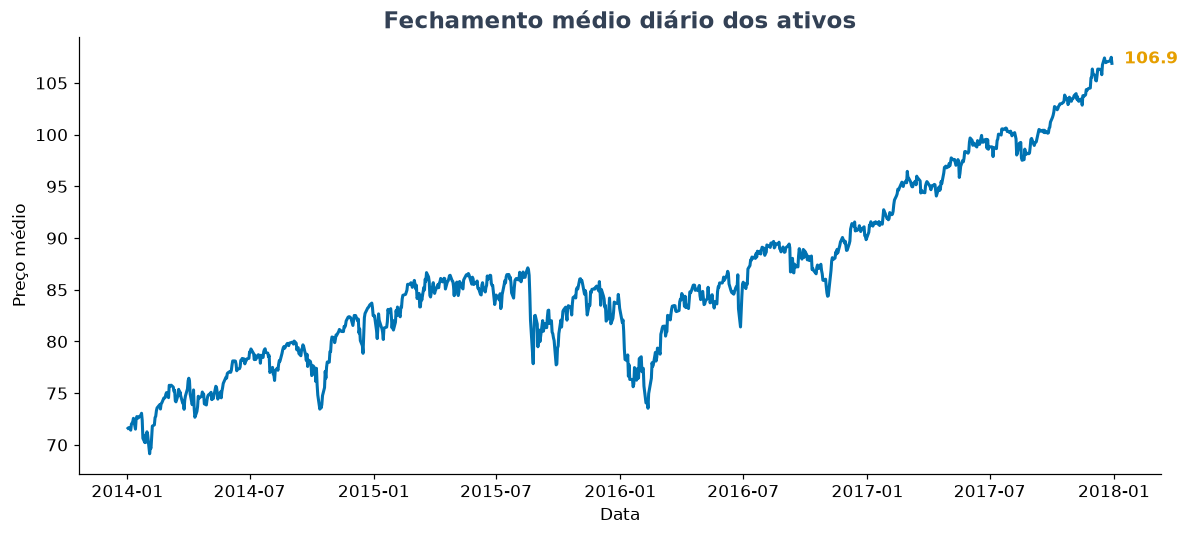

In [5]:
mercado = df.groupby('date')['close'].mean()
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(mercado.index, mercado.values, color=COR_PRIMARIA, linewidth=2)
ax.set(title='Fechamento médio diário dos ativos', xlabel='Data', ylabel='Preço médio')
ax.annotate(f'{mercado.iloc[-1]:.1f}', (mercado.index[-1], mercado.iloc[-1]), xytext=(8,0), textcoords='offset points', color=COR_DESTAQUE, fontweight='bold')
plt.tight_layout()

**Revisão crítica:** essa média é uma referência descritiva, não um índice ponderado por valor de mercado. Ela também mistura ativos com preços nominais diferentes; portanto, não deve ser interpretada como retorno do S&P 500.

## Quais ativos tiveram melhor e pior desempenho?
Vamos comparar retorno acumulado, normalizando todos os ativos pelo primeiro fechamento disponível.

In [6]:
retorno = (df.sort_values(['symbol','date']).groupby('symbol').apply(lambda g: g['close'].iloc[-1] / g['close'].iloc[0] - 1, include_groups=False).rename('retorno'))
ranking = retorno[retorno.index.notna()].sort_values()
ranking_extremos = pd.concat([ranking.head(5), ranking.tail(5)]).to_frame()
ranking_extremos

,retorno
symbol,
CHK,-0.85
RRC,-0.79
DISCA,-0.75
DISCK,-0.74
UA,-0.68
NFLX,2.70
ALGN,2.90
EA,3.60
AVGO,3.88


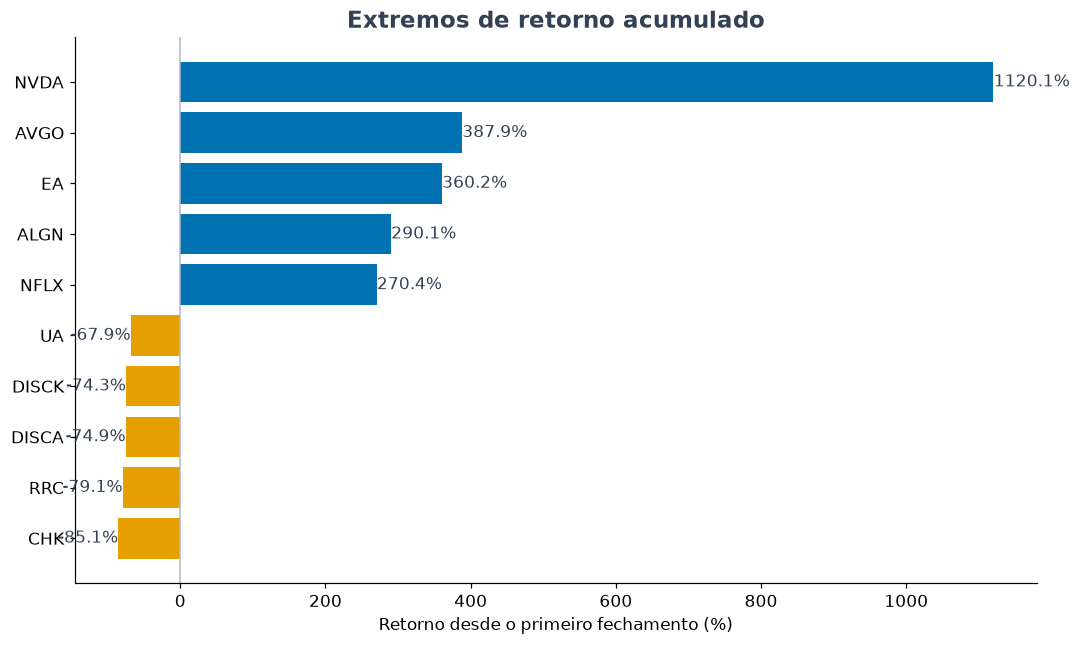

In [7]:
fig, ax = plt.subplots(figsize=(10,6))
dados = ranking_extremos['retorno'].sort_values()
cores = [COR_DESTAQUE if v < 0 else COR_PRIMARIA for v in dados.values]
ax.barh(dados.index, dados.values * 100, color=cores)
ax.axvline(0, color=COR_EIXO, linewidth=1)
for i, v in enumerate(dados.values * 100): ax.text(v + (0.5 if v >= 0 else -0.5), i, f'{v:.1f}%', va='center', ha='left' if v >= 0 else 'right')
ax.set(title='Extremos de retorno acumulado', xlabel='Retorno desde o primeiro fechamento (%)')
plt.tight_layout()

**Revisão crítica:** o ranking mede desempenho dentro da janela disponível de cada ativo; não mede risco ajustado nem causalidade. Ativos com eventos corporativos ou séries incompletas podem aparecer nos extremos e merecem validação específica.

## Qual foi o nível de oscilação diária?
Vamos medir a volatilidade dos retornos diários e comparar os ativos com pelo menos 200 observações válidas.

In [8]:
df = df.sort_values(['symbol','date'])
df['retorno_diario'] = df.groupby('symbol')['close'].pct_change()
risco = df.groupby('symbol').agg(observacoes=('retorno_diario','count'), volatilidade=('retorno_diario','std')).query('observacoes >= 200').sort_values('volatilidade')
risco_extremos = pd.concat([risco.head(5), risco.tail(5)])
risco_extremos

,observacoes,volatilidade
symbol,,
PEP,1006,0.01
PG,1006,0.01
RSG,1006,0.01
KO,1006,0.01
WM,1006,0.01
WMB,1006,0.03
FCX,1006,0.04
LNT,1006,0.04
AMD,1006,0.04


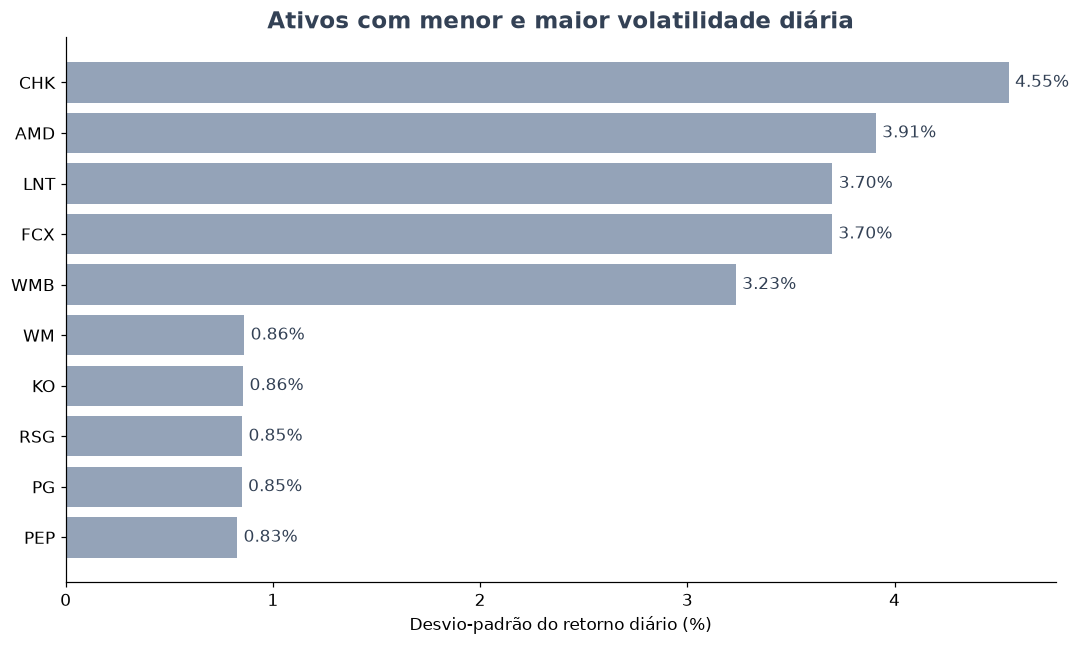

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
dados = risco_extremos['volatilidade'].sort_values() * 100
ax.barh(dados.index, dados.values, color=COR_SECUNDARIA)
for i, v in enumerate(dados.values): ax.text(v + 0.03, i, f'{v:.2f}%', va='center')
ax.set(title='Ativos com menor e maior volatilidade diária', xlabel='Desvio-padrão do retorno diário (%)')
plt.tight_layout()

**Revisão crítica:** volatilidade é uma medida de dispersão, não uma probabilidade de perda. O filtro mínimo de observações reduz comparações frágeis, mas não elimina efeitos de eventos extraordinários.

## Síntese viva
- A base contém histórico diário de preços e volume de 505 ativos entre 2014 e 2017, com 27 células ausentes e sem duplicidades.
- A evolução agregada foi apresentada apenas como referência descritiva; não equivale ao índice S&P 500.
- O desempenho deve ser comparado por retorno percentual, e o risco por volatilidade, não por preço absoluto.
- Os rankings de retorno e risco são exploratórios e devem ser aprofundados com tratamento de eventos corporativos, benchmark e possíveis séries incompletas.
- Próxima decisão técnica recomendada: definir se o objetivo será monitoramento, seleção de ativos ou estudo de risco.